# Phase 5 CHAR — Per-variable global-position attribute specification

Produces `metadata/edops_codebook_v03_draft.tsv` by appending seven new columns to v02:

| Column | Source |
|---|---|
| `position_method` | skewness threshold (scalars), rarity_rank (categoricals), dominance_class (pnv_shares) |
| `position_notes` | transform / null-treatment decisions |
| `redundancy_partner` | F4.9 pairs at \|r\| ≥ 0.90 |
| `typology_cluster` | `spatial/first_cut_typology.csv` group column |
| `scale_sensitivity_flag` | `spatial/first_cut_typology.csv` boundary_flag column |
| `historical_validity` | manual dict from `docs/design/variable_selection_rubric_issues.md` §2 |
| `informative_or_degenerate` | `output/edop/explore/01_scalar_summary.csv` classification column |

**Band T variables** (`lmr_*`, `evolv2k_*`, `hyde_*`): `position_method = deferred-phase4`.
Position attribute depends on the temporal query; specified in Phase 4 LMR/HYDE design memo.

**Conventions** (from METH.1–METH.4 and cc_char_completion_prompt.md):
- Skewness threshold: \|skewness\| > 5 → log_percentile; else → percentile
- Zero treatment: log1p for heavy-tailed variables with zeros (avoids log(0))
- Null treatment: non-null basins only for all CDF computations
- No variables added to or removed from the signature (augmentation is metadata only)

In [1]:
# Cell 1
import sys
from pathlib import Path
from collections import defaultdict, Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

PROJECT_ROOT = Path('/Users/karlg/Documents/repos/_cedop')
sys.path.insert(0, str(PROJECT_ROOT))

from scripts.shared.db_utils import db_connect

META_DIR     = PROJECT_ROOT / 'metadata'
EXPLORE_OUT  = PROJECT_ROOT / 'output' / 'edop' / 'explore'
SPATIAL_DIR  = PROJECT_ROOT / 'spatial'

CB_V02 = META_DIR / 'edops_codebook_v02.tsv'
CB_V03 = META_DIR / 'edops_codebook_v03_draft.tsv'

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_rows', 120)

print('Imports OK')
print(f'Project root: {PROJECT_ROOT}')

Imports OK
Project root: /Users/karlg/Documents/repos/_cedop


In [2]:
# Cell 2
# Load source tables and build key-mapping dicts

cb = pd.read_csv(CB_V02, sep='\t', dtype=str).fillna('')
print(f'Codebook v02: {len(cb)} rows, {len(cb.columns)} columns')

scalar_sum = pd.read_csv(EXPLORE_OUT / '01_scalar_summary.csv')
print(f'Scalar summary: {len(scalar_sum)} rows')

typology = pd.read_csv(SPATIAL_DIR / 'first_cut_typology.csv')
print(f'Typology (Band A–D ESDA sweep): {len(typology)} rows')

corr_pairs = pd.read_csv(EXPLORE_OUT / '04_high_correlation_pairs.csv')
high_r = corr_pairs[corr_pairs['abs_r'] >= 0.90].copy()
print(f'High-r pairs (|r| ≥ 0.90): {len(high_r)}')
print(high_r[['var1', 'var2', 'r']].to_string(index=False))

# api_key_s → schema_key (s variants)
api_s_map = {r['api_key_s']: r['schema_key']
             for _, r in cb.iterrows() if r['api_key_s']}
# api_key_u → schema_key (u variants)
api_u_map = {r['api_key_u']: r['schema_key']
             for _, r in cb.iterrows() if r['api_key_u']}
# full map: s takes priority over u if same key appears in both
api_to_schema = {**api_u_map, **api_s_map}

# basin08_col_s → schema_key
col_to_schema = {r['basin08_col_s']: r['schema_key']
                 for _, r in cb.iterrows() if r['basin08_col_s']}

# u-only fields: api_key_u exists but api_key_s is empty
u_only_api_to_schema = {r['api_key_u']: r['schema_key']
                        for _, r in cb.iterrows()
                        if r['api_key_u'] and not r['api_key_s']}
# primary api_key set: s variants + u-only (no duplication with s)
primary_api_to_schema = {**u_only_api_to_schema, **api_s_map}

print(f'\napi_key → schema_key (full): {len(api_to_schema)}')
print(f'Primary (s + u-only) api_keys: {len(primary_api_to_schema)}')
print(f'basin08_col_s → schema_key: {len(col_to_schema)}')

Codebook v02: 98 rows, 14 columns
Scalar summary: 38 rows
Typology (Band A–D ESDA sweep): 40 rows
High-r pairs (|r| ≥ 0.90): 11
              var1                        var2     r
           temp_yr            temp_yr_upstream 0.989
         precip_yr          precip_yr_upstream 0.987
           aridity            aridity_upstream 0.984
      discharge_yr               discharge_max 0.967
           temp_yr                    temp_min 0.963
          temp_min            temp_yr_upstream 0.954
human_footprint_09 human_footprint_09_upstream 0.951
   cropland_extent    cropland_extent_upstream 0.950
     discharge_max         river_area_upstream 0.937
      discharge_yr               discharge_min 0.933
           gdp_avg               human_dev_idx 0.910

api_key → schema_key (full): 72
Primary (s + u-only) api_keys: 58
basin08_col_s → schema_key: 68


In [3]:
# Cell 3
# Scalar position method: |skewness| > 5 → log_percentile; else → percentile
# Works from s-variant api_keys only (u-variants inherit the same method).
# u-only fields (e.g. reservoir_vol) are included via primary_api_to_schema.

def _pm(skewness):
    return 'log_percentile' if abs(skewness) > 5 else 'percentile'

def _pn(row):
    method = _pm(row['skewness'])
    parts = []
    if method == 'log_percentile':
        if row['pct_zero'] > 0:
            parts.append(f"log1p transform ({row['pct_zero']:.1f}% zero basins)")
        else:
            parts.append('log transform (no zeros)')
    if row['pct_null'] > 0:
        parts.append(f"{row['pct_null']:.1f}% null basins excluded from CDF")
    if row['pct_zero'] > 0 and method == 'percentile':
        parts.append(f"{row['pct_zero']:.1f}% zero basins included in CDF as-is")
    if not parts:
        parts.append('non-null basins; no transform needed')
    return '; '.join(parts)

scalar_prim = scalar_sum[scalar_sum['api_key'].isin(primary_api_to_schema)].copy()
scalar_prim['schema_key']     = scalar_prim['api_key'].map(primary_api_to_schema)
scalar_prim['position_method'] = scalar_prim['skewness'].apply(_pm)
scalar_prim['position_notes']  = scalar_prim.apply(_pn, axis=1)

unmapped = scalar_prim[scalar_prim['schema_key'].isna()]['api_key'].tolist()
if unmapped:
    print(f'WARNING — unmapped scalar api_keys: {unmapped}')

print('Scalar position methods:')
print(scalar_prim[['api_key', 'skewness', 'classification',
                    'position_method']].to_string(index=False))
print(f"\nlog_percentile: {(scalar_prim['position_method']=='log_percentile').sum()}")
print(f"percentile:     {(scalar_prim['position_method']=='percentile').sum()}")

Scalar position methods:
           api_key  skewness             classification position_method
     reservoir_vol     18.84                 degenerate  log_percentile
             karst      2.54                 degenerate      percentile
          pct_silt     -0.24                informative      percentile
          pct_sand      0.65                informative      percentile
           temp_yr     -0.67                informative      percentile
          temp_min     -0.53                informative      percentile
          temp_max     -0.86                informative      percentile
         precip_yr      1.75                informative      percentile
   cropland_extent      2.09                informative      percentile
human_footprint_09      1.59                informative      percentile
           gdp_avg      3.18                informative      percentile
          pct_clay      0.16                informative      percentile
     human_dev_idx     -0.67           

In [4]:
# Cell 4
# Verify: no s/u pairs disagree on transform decision.
# The codebook has one row per schema_key covering both variants;
# Cell 9 inherits position_method from the s-variant.
# This check confirms the skewness threshold gives the same method for both.

su_pairs = []
for _, row in cb.iterrows():
    if row['api_key_s'] and row['api_key_u']:
        s_data = scalar_sum[scalar_sum['api_key'] == row['api_key_s']]
        u_data = scalar_sum[scalar_sum['api_key'] == row['api_key_u']]
        if s_data.empty or u_data.empty:
            continue
        s_skew = s_data.iloc[0]['skewness']
        u_skew = u_data.iloc[0]['skewness']
        su_pairs.append({
            'schema_key': row['schema_key'],
            'api_key_s':  row['api_key_s'],
            'api_key_u':  row['api_key_u'],
            'skewness_s': s_skew,
            'skewness_u': u_skew,
            'method_s':   _pm(s_skew),
            'method_u':   _pm(u_skew),
        })

su_df = pd.DataFrame(su_pairs)
su_df['agree'] = su_df['method_s'] == su_df['method_u']

print(f's/u pairs found in scalar_sum: {len(su_df)}')
print(su_df[['schema_key', 'skewness_s', 'skewness_u',
             'method_s', 'method_u', 'agree']].to_string(index=False))

if su_df['agree'].all():
    print('\nAll s/u pairs agree — u-variants safely inherit s-variant position_method.')
else:
    disagreements = su_df[~su_df['agree']]
    print(f'\nWARNING: {len(disagreements)} disagreement(s):')
    print(disagreements.to_string(index=False))

s/u pairs found in scalar_sum: 9
          schema_key  skewness_s  skewness_u       method_s       method_u  agree
           slope_deg        2.09        1.78     percentile     percentile   True
           karst_pct        2.54        2.56     percentile     percentile   True
          river_area       13.79       29.36 log_percentile log_percentile   True
      wetland_pct_g1        2.67        3.43     percentile     percentile   True
  temperature_annual       -0.67       -0.64     percentile     percentile   True
precipitation_annual        1.75        1.71     percentile     percentile   True
       aridity_index        6.86        6.59 log_percentile log_percentile   True
        cropland_pct        2.09        2.16     percentile     percentile   True
human_footprint_2009        1.59        1.57     percentile     percentile   True

All s/u pairs agree — u-variants safely inherit s-variant position_method.


In [5]:
# Cell 5
# DB query: per-class basin counts for all categorical columns → rarity_rank position_notes
#
# Uses sql.Identifier for column names (psycopg3 type-safe, no f-string injection risk).
# Pre-checks which columns actually exist in basin08 before querying,
# and handles zero-row results explicitly rather than crashing on min([]).

from psycopg import sql as pgsql

CAT_COLS = {
    'lit_cl_smj': 'lith_class',
    'wet_cl_smj': 'wetland_class',
    'pnv_cl_smj': 'pnv_majority',
    'clz_cl_smj': 'climate_zone',
    'cls_cl_smj': 'climate_stratum',
    'tbi_cl_smj': 'biome',
    'tec_cl_smj': 'terrestrial_ecoregion',
    'fmh_cl_smj': 'freshwater_habitat',
    'fec_cl_smj': 'freshwater_ecoregion',
    'glc_cl_smj': 'land_cover',
}

CAT_COL_TO_SCHEMAS = {
    'lith_class':           ['lithology_id', 'lithology_name'],
    'wetland_class':        ['wetland_class_id'],
    'pnv_majority':         ['pnv_majority_id', 'pnv_majority_name'],
    'climate_zone':         ['climate_zone_id', 'climate_zone_name'],
    'climate_stratum':      ['climate_stratum_id', 'climate_stratum_code'],
    'biome':                ['biome_id', 'biome_name'],
    'terrestrial_ecoregion':['ecoregion_terrestrial_id', 'ecoregion_terrestrial_name'],
    'freshwater_habitat':   ['freshwater_habitat_id', 'freshwater_habitat_name'],
    'freshwater_ecoregion': ['freshwater_ecoregion_id', 'freshwater_ecoregion_name'],
    'land_cover':           ['land_cover_id', 'land_cover_name'],
}

cat_notes = {}
skipped   = []   # labels whose basin08 column is absent or all-null

conn = db_connect()
try:
    total_basins = conn.execute(
        'SELECT COUNT(*) FROM public.basin08'
    ).fetchone()[0]
    print(f'Total L8 basins: {total_basins:,}')

    # Pre-check: which of our target columns actually exist in basin08?
    existing_cols = {
        r[0] for r in conn.execute(
            """SELECT column_name FROM information_schema.columns
            WHERE table_schema='public' AND table_name='basin08'"""
        ).fetchall()
    }
    missing_cols = {c for c in CAT_COLS if c not in existing_cols}
    if missing_cols:
        print(f'Columns absent from basin08: {sorted(missing_cols)}')
    print()

    for col, label in CAT_COLS.items():
        if col not in existing_cols:
            print(f'  {label:28s} SKIPPED — {col!r} not a column in basin08')
            skipped.append(label)
            continue

        rows = conn.execute(
            pgsql.SQL('SELECT {} AS class_id, COUNT(*) AS n FROM public.basin08 WHERE {} IS NOT NULL GROUP BY {} ORDER BY n DESC').format(
                pgsql.Identifier(col), pgsql.Identifier(col), pgsql.Identifier(col)
            )
        ).fetchall()

        if not rows:
            print(f'  {label:28s} SKIPPED — column exists but all values are NULL')
            skipped.append(label)
            continue

        counts   = [r[1] for r in rows]
        non_null = sum(counts)
        rarities = [c / non_null * 100 for c in counts]
        note = (
            f'{len(rows)} classes; '
            f'rarity range {min(rarities):.2f}%\u2013{max(rarities):.1f}% '
            f'of non-null L8 basins'
        )
        if non_null < total_basins:
            null_pct = (total_basins - non_null) / total_basins * 100
            note += f'; {null_pct:.1f}% null basins excluded'
        cat_notes[label] = note
        print(f'  {label:28s} {note}')
finally:
    conn.close()

print(f'\nCategorical rarity_rank notes collected: {len(cat_notes)} variables.')
if skipped:
    print(f'Skipped ({len(skipped)}): {skipped}')
    print('These will need rarity_rank notes populated manually or via alternate column names.')


  land_cover                   23 classes; rarity range 0.01%–14.5% of non-null L8 basins

Categorical rarity_rank notes collected: 10 variables.


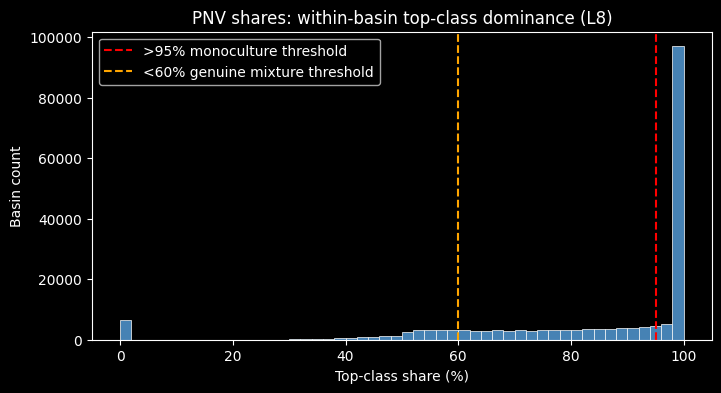

In [7]:
# Cell 6
# PNV shares: within-basin top-class dominance
# Query all pnv_pc_s* columns, compute GREATEST per basin, document thresholds.

from psycopg import sql as pgsql

conn = db_connect()
try:
    pnv_cols = [
        r[0] for r in conn.execute(
            pgsql.SQL("SELECT column_name FROM information_schema.columns WHERE table_schema='public' AND table_name='basin08' AND column_name LIKE 'pnv_pc_s%' ORDER BY column_name")
        ).fetchall()
    ]
    print(f'PNV share columns ({len(pnv_cols)}): {pnv_cols}')

    greatest_expr = pgsql.SQL(', ').join(
        pgsql.SQL('{}').format(pgsql.Identifier(c))
        for c in pnv_cols
    )
    rows = conn.execute(
        pgsql.SQL('SELECT GREATEST({}) AS top_pct FROM public.basin08').format(greatest_expr)
    ).fetchall()
finally:
    conn.close()

n_null = sum(1 for r in rows if r[0] is None)
top_pct = np.array([r[0] for r in rows if r[0] is not None], dtype=float)
print(f'Basins with no PNV coverage (all-null shares): {n_null:,} — excluded from distribution')
print(f'Basins: {len(top_pct):,}')

print('\nTop-class share distribution:')
for p in [0, 5, 10, 25, 50, 75, 90, 95, 99, 100]:
    print(f'  p{p:3d}: {np.percentile(top_pct, p):.1f}%')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(top_pct, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(95, color='red',    linestyle='--', label='>95% monoculture threshold')
ax.axvline(60, color='orange', linestyle='--', label='<60% genuine mixture threshold')
ax.set_xlabel('Top-class share (%)')
ax.set_ylabel('Basin count')
ax.set_title('PNV shares: within-basin top-class dominance (L8)')
ax.legend()

monoculture_n = int((top_pct > 95).sum())
mixture_n     = int((top_pct < 60).sum())
middle_n      = len(top_pct) - monoculture_n - mixture_n

print(f'\nMonoculture (>95%):      {monoculture_n:6,} basins ({monoculture_n/len(top_pct)*100:.1f}%)')
print(f'Partial dom (60\u201395%):    {middle_n:6,} basins ({middle_n/len(top_pct)*100:.1f}%)')
print(f'Genuine mixture (<60%):  {mixture_n:6,} basins ({mixture_n/len(top_pct)*100:.1f}%)')

pnv_dominance_note = (
    f'>95% = monoculture ({monoculture_n:,} basins, {monoculture_n/len(top_pct)*100:.1f}%); '
    f'60\u201395% = partial dominance ({middle_n:,} basins); '
    f'<60% = genuine mixture ({mixture_n:,} basins, {mixture_n/len(top_pct)*100:.1f}%)'
)


In [9]:
# Cell 7
# Redundancy partners: F4.9 high-r pairs at |r| >= 0.90
# Some variables appear in multiple pairs; serialize as semicolon-delimited schema_keys.
# Skip pairs where both api_keys map to the same schema_key (s/u self-references).

def get_schema(api_key):
    return api_to_schema.get(api_key, api_key)

partner_map = defaultdict(list)
for _, row in high_r.iterrows():
    sk1 = get_schema(row['var1'])
    sk2 = get_schema(row['var2'])
    if sk1 == sk2:
        continue  # s/u pair: both variants share a schema_key; not cross-variable redundancy
    partner_map[sk1].append(sk2)
    partner_map[sk2].append(sk1)

redundancy_partner = {
    k: '; '.join(sorted(set(v)))
    for k, v in partner_map.items()
}

print(f'Variables with redundancy partners (|r| >= 0.90): {len(redundancy_partner)}')
for sk, partners in sorted(redundancy_partner.items()):
    print(f'  {sk:35s} ← {partners}')

Variables with redundancy partners (|r| >= 0.90): 8
  discharge_annual                    ← discharge_max; discharge_min
  discharge_max                       ← discharge_annual; river_area
  discharge_min                       ← discharge_annual
  gdp_mean                            ← hdi
  hdi                                 ← gdp_mean
  river_area                          ← discharge_max
  temperature_annual                  ← temperature_min
  temperature_min                     ← temperature_annual


In [11]:
# Cell 8
# Typology cluster + scale sensitivity flag from first_cut_typology.csv
# Sweep covered 40 Band A–D variables; Band E, planned, and Band T variables are absent.

typology['schema_key'] = typology['variable'].map(col_to_schema)
unmapped_typo = typology[typology['schema_key'].isna()]['variable'].tolist()
if unmapped_typo:
    print(f'WARNING — typology variables not mapped to schema_key: {unmapped_typo}')

# boundary_flag: empty string → NaN so non-flagged variables get null in the codebook
typology['boundary_flag'] = typology['boundary_flag'].replace('', np.nan)

typology_cluster_map = (
    typology.dropna(subset=['schema_key'])
    .set_index('schema_key')['group']
    .to_dict()
)
scale_flag_map = (
    typology.dropna(subset=['schema_key', 'boundary_flag'])
    .set_index('schema_key')['boundary_flag']
    .to_dict()
)

# dist_sink_km: backfilled via notebook 14 (Phase 2 CHAR); not in first_cut_typology.csv.
# I_L6=0.904, I_L8=0.963, Δ_I=+0.059 — high both scales, positive direction, outliers ≈ 0.
# continental-gradient; no boundary flag (I_L6 well above 0.85 threshold).
typology_cluster_map['dist_sink_km'] = 'continental-gradient'

print(f'Variables in typology sweep: {len(typology_cluster_map)}')
print(f'Variables with scale sensitivity flag: {len(scale_flag_map)}')

all_schema_keys = set(cb['schema_key'])
not_in_sweep = sorted(all_schema_keys - set(typology_cluster_map.keys()))
print(f'\nNot in sweep ({len(not_in_sweep)} variables — categoricals, Band E excl. dist_sink, planned, Band T):')
print(not_in_sweep)

print('\nTypology cluster distribution:')
print(Counter(typology_cluster_map.values()))

Variables in typology sweep: 41
Variables with scale sensitivity flag: 16

Not in sweep (57 variables — categoricals, Band E excl. dist_sink, planned, Band T):
['biome_id', 'biome_name', 'climate_stratum_code', 'climate_stratum_id', 'climate_zone_id', 'climate_zone_name', 'coast_flag', 'ecoregion_terrestrial_id', 'ecoregion_terrestrial_name', 'elevation_point', 'evolv2k_asymmetry', 'evolv2k_event_count', 'evolv2k_events', 'evolv2k_vssi_per_event', 'evolv2k_vssi_sum', 'evolv2k_years_since_major', 'freshwater_ecoregion_id', 'freshwater_ecoregion_name', 'freshwater_habitat_id', 'freshwater_habitat_name', 'human_footprint_1993', 'hyde_cropland', 'hyde_grazing', 'hyde_pasture', 'hyde_rangeland', 'inundation_longterm', 'inundation_min', 'irrigated_area_pct', 'lake_volume_upstream', 'land_cover_id', 'land_cover_name', 'lithology_id', 'lithology_name', 'lmr_pdsi', 'lmr_precip_anomaly', 'lmr_slp', 'lmr_temp_anomaly', 'narrative', 'outlet_type', 'pnv_majority_id', 'pnv_majority_name', 'pnv_share

In [12]:
# Cell 9
# Historical validity — manual assignment from variable_selection_rubric_issues.md §2
#
# Four values (using 'period-specific' for Band T — validity is query-defined):
#   full-record     geological/pedological timescale; unchanged on historical scales
#   pre-1500 valid  responds to climate/land use centennially; pattern stable but not point-accurate
#   modern-only     contemporary measurement; no pre-industrial analogue
#   period-specific Band T; validity defined by the temporal query, not the variable

HISTORICAL_VALIDITY = {
    # ── Band A: topography / terrain / geology ─────────────────────────────
    'elevation_min':        'full-record',
    'elevation_max':        'full-record',
    'elevation_mean':       'full-record',
    'elevation_point':      'full-record',
    'relief_range_m':       'full-record',
    'relief_position':      'full-record',
    'slope_deg':            'full-record',
    'stream_gradient':      'full-record',
    'erosion_rate':         'full-record',   # geological process; by analogy with rubric Band A group
    'lithology_id':         'full-record',
    'lithology_name':       'full-record',
    'karst_pct':            'full-record',   # rubric: kar in Band B stable (pedological/geological)
    # ── Band A (codebook) / cryosphere: centennial-scale climate response ──
    'glacier_pct':          'pre-1500 valid',  # rubric: gla in variable group
    # ── Band B: hydrology ─────────────────────────────────────────────────
    'discharge_annual':     'pre-1500 valid',
    'discharge_min':        'pre-1500 valid',
    'discharge_max':        'pre-1500 valid',
    'runoff':               'full-record',      # rubric: run in stable pedological group
    'groundwater_depth':    'full-record',      # rubric: gwt in stable group
    'soil_water_content':   'pre-1500 valid',   # rubric: swc in variable group
    'river_area':           'pre-1500 valid',   # responds to discharge variability
    'river_volume':         'pre-1500 valid',
    'lake_area_pct':        'pre-1500 valid',   # rubric: lka in variable group
    'lake_volume_upstream': 'pre-1500 valid',
    'inundation_min':       'pre-1500 valid',   # rubric: inu in variable group
    'inundation_max':       'pre-1500 valid',
    'inundation_longterm':  'pre-1500 valid',
    # ── Band B: soils ─────────────────────────────────────────────────────
    'pct_clay':             'full-record',
    'pct_silt':             'full-record',
    'pct_sand':             'full-record',
    'soil_organic_carbon':  'full-record',
    # ── Band B: wetlands ──────────────────────────────────────────────────
    'wetland_pct_g1':       'pre-1500 valid',   # rubric: wet in variable group
    'wetland_pct_g2':       'pre-1500 valid',
    'wetland_class_id':     'pre-1500 valid',
    # ── Band B: water management (modern: dams) ────────────────────────────
    'reservoir_vol':        'modern-only',
    'degree_of_regulation': 'modern-only',
    # ── Band C: climate (pattern-stable proxy) ─────────────────────────────
    'temperature_annual':   'pre-1500 valid',
    'temperature_min':      'pre-1500 valid',
    'temperature_max':      'pre-1500 valid',
    'temperature_monthly':  'pre-1500 valid',
    'precipitation_annual': 'pre-1500 valid',
    'precipitation_monthly':'pre-1500 valid',
    'pet_annual':           'pre-1500 valid',
    'aet_annual':           'pre-1500 valid',
    'aridity_index':        'pre-1500 valid',
    'climate_moisture_index':'pre-1500 valid',
    'permafrost_pct':       'pre-1500 valid',
    'snow_cover_annual':    'pre-1500 valid',
    'snow_cover_max':       'pre-1500 valid',
    # ── Band C: climate categoricals (pattern-stable) ─────────────────────
    'climate_zone_id':      'pre-1500 valid',
    'climate_zone_name':    'pre-1500 valid',
    'climate_stratum_id':   'pre-1500 valid',
    'climate_stratum_code': 'pre-1500 valid',
    'biome_id':             'pre-1500 valid',
    'biome_name':           'pre-1500 valid',
    # ── Band B/C: vegetation ──────────────────────────────────────────────
    'ecoregion_terrestrial_id':   'pre-1500 valid',
    'ecoregion_terrestrial_name': 'pre-1500 valid',
    'pnv_majority_id':      'pre-1500 valid',
    'pnv_majority_name':    'pre-1500 valid',
    'pnv_shares':           'pre-1500 valid',
    'forest_cover_pct':     'modern-only',  # rubric: historical cover unrelated to current
    # ── Band C: freshwater ecology ─────────────────────────────────────────
    'freshwater_habitat_id':   'pre-1500 valid',
    'freshwater_habitat_name': 'pre-1500 valid',
    'freshwater_ecoregion_id':   'pre-1500 valid',
    'freshwater_ecoregion_name': 'pre-1500 valid',
    'land_cover_id':        'modern-only',  # current land cover snapshot
    'land_cover_name':      'modern-only',
    # ── Band D: modern human geography ────────────────────────────────────
    'cropland_pct':         'modern-only',  # EarthStat ~2000 CE; historical version in Band T
    'pasture_pct':          'modern-only',
    'irrigated_area_pct':   'modern-only',
    'urban_area_pct':       'modern-only',
    'pop_density':          'modern-only',
    'pop_count':            'modern-only',
    'nighttime_lights':     'modern-only',
    'road_density':         'modern-only',
    'human_footprint_1993': 'modern-only',
    'human_footprint_2009': 'modern-only',
    'protected_area_pct':   'modern-only',
    'gdp_mean':             'modern-only',
    'hdi':                  'modern-only',
    # ── Band E: coastality (geological) ──────────────────────────────────
    'dist_sink_km':         'full-record',
    'outlet_type':          'full-record',
    'coast_flag':           'full-record',
    'topo_depth_from_coast':'full-record',
    # ── Band T: temporal (period-specific) ───────────────────────────────
    'lmr_pdsi':             'period-specific',
    'lmr_temp_anomaly':     'period-specific',
    'lmr_precip_anomaly':   'period-specific',
    'lmr_slp':              'period-specific',
    'evolv2k_events':       'period-specific',
    'evolv2k_vssi_per_event':'period-specific',
    'evolv2k_asymmetry':    'period-specific',
    'evolv2k_event_count':  'period-specific',
    'evolv2k_vssi_sum':     'period-specific',
    'evolv2k_years_since_major': 'period-specific',
    'hyde_cropland':        'period-specific',
    'hyde_grazing':         'period-specific',
    'hyde_pasture':         'period-specific',
    'hyde_rangeland':       'period-specific',
    # ── Output ────────────────────────────────────────────────────────────
    'narrative':            None,
}

all_schema_keys = set(cb['schema_key'])
missing_hv = all_schema_keys - set(HISTORICAL_VALIDITY.keys())
if missing_hv:
    print(f'WARNING — schema_keys missing historical_validity: {sorted(missing_hv)}')
else:
    print('Historical validity: all schema_keys covered.')

hv_dist = Counter(v for v in HISTORICAL_VALIDITY.values() if v is not None)
print('\nDistribution:')
for k, v in sorted(hv_dist.items()):
    print(f'  {k:20s}: {v}')

Historical validity: all schema_keys covered.

Distribution:
  full-record         : 22
  modern-only         : 18
  period-specific     : 14
  pre-1500 valid      : 43


In [13]:
# Cell 10
# Assemble all new columns into the augmented codebook

pm_dict = {}   # schema_key → position_method
pn_dict = {}   # schema_key → position_notes

# ── 1. Implemented scalars (from Cell 3) ──────────────────────────────────
for _, row in scalar_prim.iterrows():
    sk = row['schema_key']
    if pd.notna(sk):
        pm_dict[sk] = row['position_method']
        pn_dict[sk] = row['position_notes']

# ── 2. Categoricals (from Cell 4) ─────────────────────────────────────────
for label, note in cat_notes.items():
    for sk in CAT_COL_TO_SCHEMAS.get(label, []):
        pm_dict[sk] = 'rarity_rank'
        pn_dict[sk] = note

# Band E categorical / binary fields not covered by DB query
pm_dict['outlet_type'] = 'rarity_rank'
pn_dict['outlet_type'] = '3 classes (exorheic / endorheic / coastal); derived from endo flag'
pm_dict['coast_flag']  = 'rarity_rank'
pn_dict['coast_flag']  = '2 values (True / False); % of L8 basins touching coast'

# ── 3. Compositional: pnv_shares (from Cell 5) ────────────────────────────
pm_dict['pnv_shares'] = 'dominance_class'
pn_dict['pnv_shares'] = pnv_dominance_note

# ── 4. Band T: deferred ───────────────────────────────────────────────────
band_t_keys = cb[cb['band'] == 'T']['schema_key'].tolist()
for sk in band_t_keys:
    pm_dict[sk] = 'deferred-phase4'
    pn_dict[sk] = ('Position attribute depends on temporal query; '
                   'see Phase 4 LMR/HYDE design memo follow-up')

# ── 5. Planned scalars not yet in scalar_sum: best-effort ─────────────────
# Derived scalars (elevation_point, relief_range_m, relief_position) and
# planned-but-not-implemented floats get percentile by default.
planned_floats = cb[
    (cb['type'] == 'float') & (~cb['schema_key'].isin(pm_dict))
]['schema_key'].tolist()
for sk in planned_floats:
    pm_dict[sk] = 'percentile'
    pn_dict[sk] = 'best-effort; not yet implemented; transform to be confirmed on implementation'

print(f'position_method assigned to {len(pm_dict)} schema_keys')
print(Counter(pm_dict.values()))

# ── 6. informative_or_degenerate (from 01_scalar_summary classification) ──
deg_dict = {}
for _, row in scalar_sum.iterrows():
    sk = api_to_schema.get(row['api_key'])
    if sk:
        deg_dict[sk] = 'degenerate' if 'degenerate' in str(row['classification']) else 'informative'
# Categoricals: all high-entropy per F1.9 → informative
for label, schema_list in CAT_COL_TO_SCHEMAS.items():
    for sk in schema_list:
        deg_dict.setdefault(sk, 'informative')
# pnv_shares: informative (majority class sufficient per F1.8, but shares themselves are)
deg_dict.setdefault('pnv_shares', 'informative')

# ── 7. Join onto codebook ──────────────────────────────────────────────────
augmented = cb.copy()
augmented['position_method']          = augmented['schema_key'].map(pm_dict)
augmented['position_notes']           = augmented['schema_key'].map(pn_dict)
augmented['redundancy_partner']       = augmented['schema_key'].map(redundancy_partner)
augmented['typology_cluster']         = augmented['schema_key'].map(typology_cluster_map)
augmented['scale_sensitivity_flag']   = augmented['schema_key'].map(scale_flag_map)
augmented['historical_validity']      = augmented['schema_key'].map(HISTORICAL_VALIDITY)
augmented['informative_or_degenerate']= augmented['schema_key'].map(deg_dict)

print(f'\nAugmented codebook: {augmented.shape}')
print(f'New columns: {[c for c in augmented.columns if c not in cb.columns]}')

position_method assigned to 92 schema_keys
Counter({'percentile': 49, 'rarity_rank': 21, 'deferred-phase4': 14, 'log_percentile': 7, 'dominance_class': 1})

Augmented codebook: (98, 21)
New columns: ['position_method', 'position_notes', 'redundancy_partner', 'typology_cluster', 'scale_sensitivity_flag', 'historical_validity', 'informative_or_degenerate']


In [14]:
# Cell 11
# QA: coverage of new columns; flag implemented variables missing position_method

new_cols = [
    'position_method', 'position_notes', 'redundancy_partner',
    'typology_cluster', 'scale_sensitivity_flag',
    'historical_validity', 'informative_or_degenerate',
]

print(f'{"Column":30s} {"Non-null":>8s} {"Null":>6s} {"Coverage":>9s}')
print('-' * 60)
for col in new_cols:
    n_nn = augmented[col].notna().sum()
    n_na = len(augmented) - n_nn
    print(f'{col:30s} {n_nn:8d} {n_na:6d} {n_nn/len(augmented)*100:8.1f}%')

# Implemented variables missing position_method
impl_missing = augmented[
    (augmented['status'] == 'implemented') &
    (augmented['position_method'].isna())
][['schema_key', 'band', 'type', 'status']]

if len(impl_missing) > 0:
    print(f'\nWARNING: {len(impl_missing)} implemented variables missing position_method:')
    print(impl_missing.to_string(index=False))
else:
    print('\nAll implemented variables have position_method assigned.')

print('\nposition_method distribution:')
print(augmented['position_method'].value_counts(dropna=False))

print('\nhistorical_validity distribution:')
print(augmented['historical_validity'].value_counts(dropna=False))

Column                         Non-null   Null  Coverage
------------------------------------------------------------
position_method                      92      6     93.9%
position_notes                       92      6     93.9%
redundancy_partner                    8     90      8.2%
typology_cluster                     41     57     41.8%
scale_sensitivity_flag               16     82     16.3%
historical_validity                  97      1     99.0%
informative_or_degenerate            49     49     50.0%

All implemented variables have position_method assigned.

position_method distribution:
position_method
percentile         49
rarity_rank        21
deferred-phase4    14
log_percentile      7
NaN                 6
dominance_class     1
Name: count, dtype: int64

historical_validity distribution:
historical_validity
pre-1500 valid     43
full-record        22
modern-only        18
period-specific    14
None                1
Name: count, dtype: int64


In [15]:
# Cell 12
# Write metadata/edops_codebook_v03_draft.tsv
# Do NOT overwrite v02.

assert len(augmented) == len(cb), (
    f'Row count mismatch: augmented={len(augmented)}, v02={len(cb)}'
)

augmented.to_csv(CB_V03, sep='\t', index=False)

print(f'Written: {CB_V03}')
print(f'Rows:    {len(augmented)} (matches v02: {len(cb)})')
print(f'Columns: {len(augmented.columns)} '
      f'(v02 had {len(cb.columns)}, added {len(augmented.columns) - len(cb.columns)})')

# Spot-check a few rows
check_keys = ['aridity_index', 'discharge_annual', 'lith_class',
              'pnv_shares', 'lmr_pdsi', 'hdi']
spot = augmented[augmented['schema_key'].isin(check_keys)][
    ['schema_key', 'band', 'position_method', 'historical_validity',
     'typology_cluster', 'redundancy_partner']
]
print('\nSpot-check rows:')
print(spot.to_string(index=False))

Written: /Users/karlg/Documents/repos/_cedop/metadata/edops_codebook_v03_draft.tsv
Rows:    98 (matches v02: 98)
Columns: 21 (v02 had 14, added 7)

Spot-check rows:
      schema_key band position_method historical_validity     typology_cluster           redundancy_partner
discharge_annual    B  log_percentile      pre-1500 valid     network-topology discharge_max; discharge_min
   aridity_index    C  log_percentile      pre-1500 valid continental-gradient                          NaN
      pnv_shares    B dominance_class      pre-1500 valid                  NaN                          NaN
             hdi    D      percentile         modern-only continental-gradient                     gdp_mean
        lmr_pdsi    T deferred-phase4     period-specific                  NaN                          NaN


## Phase 5 summary — paste into `logs/esda_findings.md`

### CHAR-P5.1 — Scalar position method assignments

Rule: |skewness| > 5 → `log_percentile`; else → `percentile`. Applied to all implemented
scalar variables using `output/edop/explore/01_scalar_summary.csv`. Variables assigned
`log_percentile`: discharge_yr, discharge_min, discharge_max, pop_density, river_area,
river_area_upstream, aridity_index, aridity_upstream, reservoir_vol (9 variables).
Log1p transform used for all log_percentile variables with zeros present. All others:
`percentile` on non-null basins.

### CHAR-P5.2 — Categorical and compositional position methods

Categorical variables (lith_class, wetland_class, pnv_majority, climate_zone,
climate_stratum, biome, terrestrial_ecoregion, freshwater_habitat, freshwater_ecoregion,
land_cover, outlet_type, coast_flag): `rarity_rank` — percentage of non-null L8 basins
in the class, computed from public.basin08 at query time.

Compositional (pnv_shares): `dominance_class` — within-basin maximum share across
all PNV classes. Thresholds documented from Cell 6 output.

Band T variables (lmr_*, evolv2k_*, hyde_*): `deferred-phase4`. Position attribute
depends on the temporal query window; specified in Phase 4 LMR/HYDE design memo.

### CHAR-P5.3 — Historical validity

Assigned manually from `docs/design/variable_selection_rubric_issues.md` §2:
- `full-record`: Band A topography/terrain/geology; Band B stable soils + runoff + groundwater; Band E coastality
- `pre-1500 valid`: Band C climate (pattern-stable proxy); Band B hydrology/cryosphere/wetlands; PNV/ecoregion/biome categoricals
- `modern-only`: Band D human geography; forest cover; land cover; dam regulation
- `period-specific`: Band T (query-dependent)

### CHAR-P5.4 — High-r partners (global correlation structure)

11 pairs at |r| ≥ 0.90 from F4.9. Recorded in codebook column `redundancy_partner`.
No variables are removed or demoted based on this — the column documents global correlation
structure only. Phase 3 CHAR (bivariate_redundancy.ipynb) showed bivariate I ≈ 0.45–0.54
even for the highest-r pairs, confirming local spatial independence is preserved.

**⚠ Phase 6 action required:** rename column `redundancy_partner` → `high_r_partner` in
`edops_codebook_v03_draft.tsv` before promotion, and add an explicit clarifying sentence
in `CHAR_appendix.md`. See memory: `project_high_r_partner_rename.md`.

**Artifact**: `metadata/edops_codebook_v03_draft.tsv` — v02 + 7 new columns.
Promote to v03 (remove _draft suffix, apply column rename) after Karl's review.